# Import

In [58]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Plot settings
plt.rcParams["figure.figsize"] = (10, 6)

In [59]:
file_path = "tmc_summary_data.csv"

df = pd.read_csv(file_path)

In [60]:
df.head()

,_id,count_id,count_date,location_name,longitude,latitude,centreline_type,centreline_id,px,count_duration,total_vehicle,total_bike,total_heavy_pct,total_pedestrian,am_peak_start,am_peak_vehicle,am_peak_bike,am_peak_heavy_pct,pm_peak_start,pm_peak_vehicle,pm_peak_bike,pm_peak_heavy_pct,n_appr_vehicle,n_appr_bike,n_appr_heavy_pct,e_appr_vehicle,e_appr_bike,e_appr_heavy_pct,s_appr_vehicle,s_appr_bike,s_appr_heavy_pct,w_appr_vehicle,w_appr_bike,w_appr_heavy_pct
0,1,116929,2026-08-26,Kennedy Rd / Lawrence Ave E,-79.27,43.75,2,13450163,412.00,14,54144,266,0.05,5963,2026-08-26T08:15:00,3633,13,0.06,2026-08-26T17:00:00,4870,19,0.03,13988,63,0.04,16728,94,0.03,8733,63,0.10,14695,46,0.03
1,2,116974,2026-08-26,Monarch Park Ave / Sammon Ave (West),-79.33,43.69,2,13460149,"5,575.00",14,2429,437,0.01,734,2026-08-26T08:15:00,205,39,0.00,2026-08-26T16:30:00,299,81,0.00,337,32,0.01,803,151,0.01,615,116,0.01,674,138,0.01
2,3,116930,2026-08-25,Lawrence Ave E / Midland Ave,-79.27,43.75,2,13449830,413.00,14,48664,352,0.05,6127,2026-08-25T08:15:00,3252,20,0.06,2026-08-25T16:45:00,4461,46,0.03,9081,89,0.11,14670,98,0.04,9495,83,0.04,15418,82,0.03
3,4,116989,2026-08-25,Midland Ave: Lawrence Ave E - Treewood St,-79.27,43.75,1,5087274,NaN,14,20562,148,0.07,730,2026-08-25T08:15:00,1422,8,0.08,2026-08-25T17:15:00,1862,12,0.05,9423,93,0.11,0,0,0.00,10499,52,0.05,640,3,0.02
4,5,116975,2026-08-25,Yore Rd / Trethewey Dr,-79.48,43.69,2,13459985,469.00,14,24316,173,0.04,652,2026-08-25T08:00:00,1923,9,0.05,2026-08-25T17:00:00,2130,22,0.02,6917,35,0.04,6369,52,0.06,11030,84,0.04,0,2,0.00


In [61]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 30,867
Number of columns: 34


# EDA — Distribution of busiest intersactions

In [62]:
df.head()

,_id,count_id,count_date,location_name,longitude,latitude,centreline_type,centreline_id,px,count_duration,total_vehicle,total_bike,total_heavy_pct,total_pedestrian,am_peak_start,am_peak_vehicle,am_peak_bike,am_peak_heavy_pct,pm_peak_start,pm_peak_vehicle,pm_peak_bike,pm_peak_heavy_pct,n_appr_vehicle,n_appr_bike,n_appr_heavy_pct,e_appr_vehicle,e_appr_bike,e_appr_heavy_pct,s_appr_vehicle,s_appr_bike,s_appr_heavy_pct,w_appr_vehicle,w_appr_bike,w_appr_heavy_pct
0,1,116929,2026-08-26,Kennedy Rd / Lawrence Ave E,-79.27,43.75,2,13450163,412.00,14,54144,266,0.05,5963,2026-08-26T08:15:00,3633,13,0.06,2026-08-26T17:00:00,4870,19,0.03,13988,63,0.04,16728,94,0.03,8733,63,0.10,14695,46,0.03
1,2,116974,2026-08-26,Monarch Park Ave / Sammon Ave (West),-79.33,43.69,2,13460149,"5,575.00",14,2429,437,0.01,734,2026-08-26T08:15:00,205,39,0.00,2026-08-26T16:30:00,299,81,0.00,337,32,0.01,803,151,0.01,615,116,0.01,674,138,0.01
2,3,116930,2026-08-25,Lawrence Ave E / Midland Ave,-79.27,43.75,2,13449830,413.00,14,48664,352,0.05,6127,2026-08-25T08:15:00,3252,20,0.06,2026-08-25T16:45:00,4461,46,0.03,9081,89,0.11,14670,98,0.04,9495,83,0.04,15418,82,0.03
3,4,116989,2026-08-25,Midland Ave: Lawrence Ave E - Treewood St,-79.27,43.75,1,5087274,NaN,14,20562,148,0.07,730,2026-08-25T08:15:00,1422,8,0.08,2026-08-25T17:15:00,1862,12,0.05,9423,93,0.11,0,0,0.00,10499,52,0.05,640,3,0.02
4,5,116975,2026-08-25,Yore Rd / Trethewey Dr,-79.48,43.69,2,13459985,469.00,14,24316,173,0.04,652,2026-08-25T08:00:00,1923,9,0.05,2026-08-25T17:00:00,2130,22,0.02,6917,35,0.04,6369,52,0.06,11030,84,0.04,0,2,0.00


In [63]:
print("Earliest count date:", df["count_date"].min())
print("Latest count date:", df["count_date"].max())

Earliest count date: 1984-01-03
Latest count date: 2026-08-26


In [64]:
df["count_date"] = pd.to_datetime(
    df["count_date"],
    errors="coerce"
)

In [65]:
df["count_year"] = df["count_date"].dt.year

In [66]:
df["count_year"].value_counts().sort_index()

count_year
1984     537
1985     457
1986     555
1987     383
1988     142
1989     646
1990     362
1991     573
1992     344
1993     373
1994     449
1995     591
1996     536
1997     465
1998     481
1999     618
2000     675
2001     826
2002     818
2003     917
2004     745
2005     790
2006     812
2007     796
2008     673
2009     794
2010     795
2011     661
2012     620
2013     483
2014     565
2015     623
2016    1038
2017     589
2018     823
2019     717
2020     875
2021    1139
2022    2185
2023    1031
2024    1418
2025    1344
2026     603
Name: count, dtype: int64

In [67]:
df["year"] = df["count_date"].dt.year


In [68]:
df_2025 = df[df["year"] == 2025].copy()
df_2025["year"].value_counts()

year
2025    1344
Name: count, dtype: int64

In [69]:
# Create total traffic volume
df_2025["total_traffic"] = (
    df_2025["total_vehicle"] +
    df_2025["total_bike"] +
    df_2025["total_pedestrian"]
)

# Preview the result
df_2025[
    [
        "location_name",
        "total_vehicle",
        "total_bike",
        "total_pedestrian",
        "total_traffic"
    ]
].head()

,location_name,total_vehicle,total_bike,total_pedestrian,total_traffic
604,Albion Rd / Todd Brook Dr,23125,20,176,23321
605,Linkwood Lane / Edgecliff Golfway,8084,6,504,8594
606,Borough Dr / Town Centre Crt (North),12628,18,1566,14212
607,Homewood Ave / Maitland Pl,3451,150,2029,5630
608,Marlee Ave / Livingstone Ave,6155,23,929,7107


In [70]:
top_traffic_locations = (
    df_2025[
        [
            "location_name",
            "total_vehicle",
            "total_bike",
            "total_pedestrian",
            "total_traffic"
        ]
    ]
    .sort_values("total_traffic", ascending=False)
    .head(10)
)

top_traffic_locations

,location_name,total_vehicle,total_bike,total_pedestrian,total_traffic
1469,Bay St / Front St W,21960,1992,89502,113454
1811,Dundas St E / Yonge St / Dundas St W,15962,3454,91808,111224
1830,Dundas St E / Yonge St / Dundas St W,19520,2243,75973,97736
1507,Ellesmere Rd / Kennedy Rd,72545,214,8176,80935
1487,Bay St / Wellington St W,21722,1590,54618,77930
1534,Bay St / Bloor St W,24218,6427,46129,76774
873,Sheppard Ave E / Yonge St / Sheppard Ave W,54597,400,20006,75003
1128,Bay St / Dundas St W,28353,4137,39899,72389
1471,Bay St / King St W,16714,2944,51782,71440
1460,Bay St / Adelaide St W,21595,4132,43168,68895


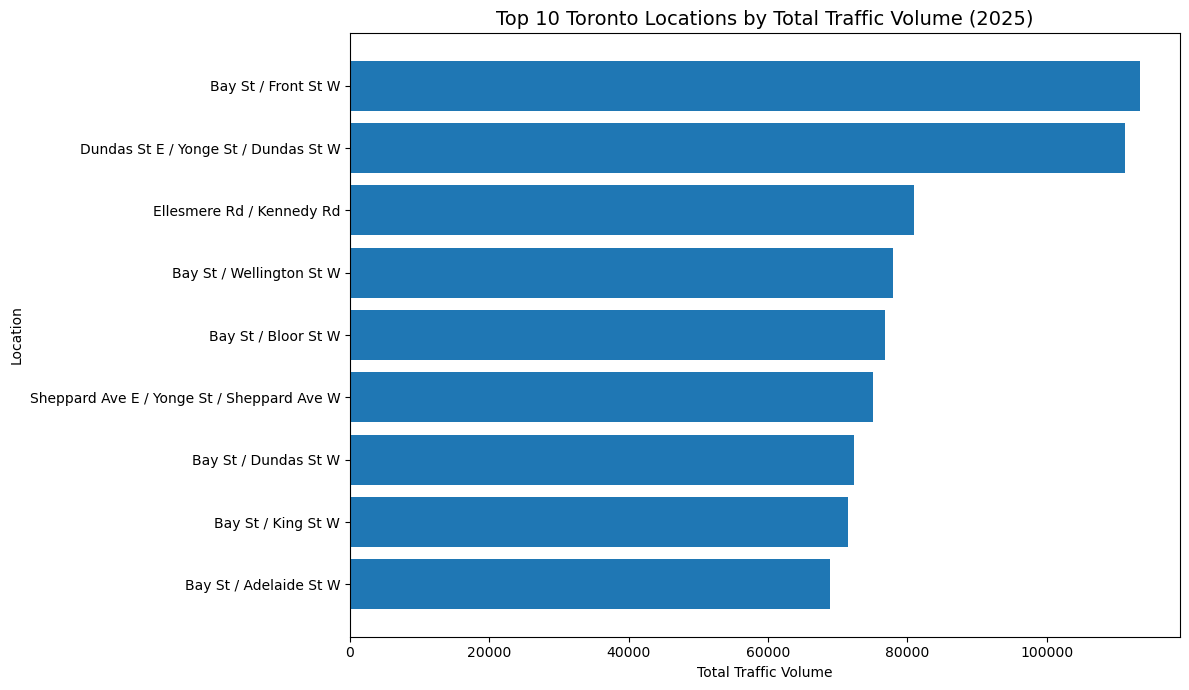

In [71]:
# Sort ascending for horizontal bar chart
top_traffic_plot = top_traffic_locations.sort_values(
    "total_traffic",
    ascending=True
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_traffic_plot["location_name"],
    top_traffic_plot["total_traffic"]
)

plt.title(
    "Top 10 Toronto Locations by Total Traffic Volume (2025)",
    fontsize=14
)

plt.xlabel("Total Traffic Volume")
plt.ylabel("Location")

plt.tight_layout()
plt.show()